## Impulse Response Verification

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import control
from numpy import sin, cos, tan, pi
from control import TransferFunction as TF

## Laplace Solution from Lecture Slides

In [14]:
m = 1
k = 10
b = 0.5

In [15]:
b_cr = 2*np.sqrt(k*m)
b_cr

np.float64(6.324555320336759)

In [16]:
wn = np.sqrt(10)
wn

np.float64(3.1622776601683795)

In [17]:
z = 0.5/b_cr
z

np.float64(0.07905694150420949)

In [18]:
2*z*wn

np.float64(0.5)

In [19]:
w = np.sqrt(10-0.25**2)
w

np.float64(3.152380053229623)

In [20]:
A = 1/w
A

np.float64(0.31722063428725766)

In [22]:
a = z*wn
a

np.float64(0.25)

In [26]:
t = np.arange(0,10,0.01)

In [27]:
x_laplace = A*np.exp(-a*t)*np.sin(w*t)

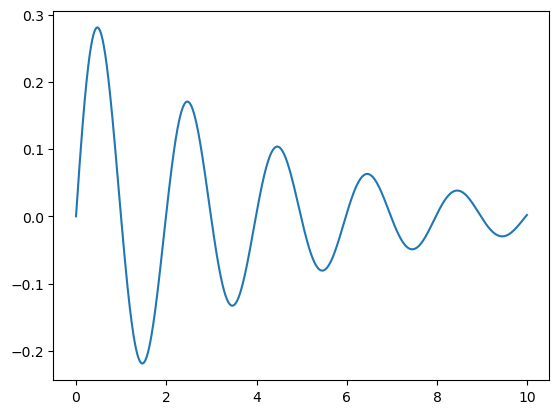

In [28]:
plt.figure()
plt.plot(t,x_laplace)

## Python Verification

$$G(s) = \frac{X(s)}{F(s)} = \frac{1/m}{s^2 + 2 \zeta \omega_n s + \omega_n^2}$$

In [29]:
G = TF(1/m,[1,2*z*wn,wn**2])
G

TransferFunction(
array([1.]),
array([ 1. ,  0.5, 10. ]),
outputs=1, inputs=1)

In [31]:
to, x_imp_py = control.impulse_response(G,t)

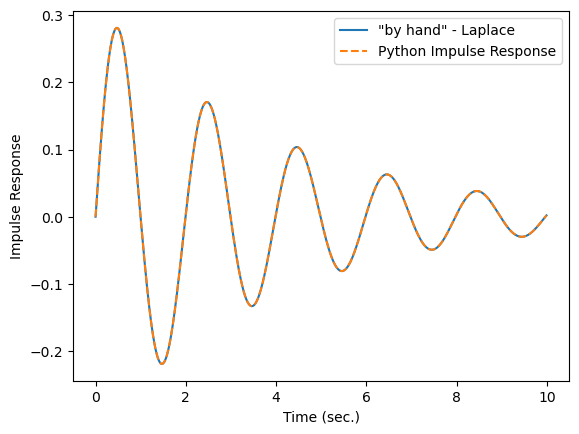

In [34]:
plt.figure()
plt.plot(t,x_laplace)
plt.plot(t,x_imp_py,'--')
plt.xlabel('Time (sec.)')
plt.ylabel('Impulse Response')
plt.legend(['"by hand" - Laplace','Python Impulse Response'])